---
title: Two fields — a spatial scale as well
subtitle: Letting the GEV scale σ(s) vary in space alongside the location μ(s)
short_title: Spatial μ and σ
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - non-stationary extremes
  - Gaussian process
  - spatial scale
  - variational inference
  - return levels
abstract: |
  Notebook 07 let the GEV location μ(s) roam as a Gaussian process while the
  scale σ and shape ξ stayed global. Here we give the **scale its own field**
  too: log σ(s) becomes a second, independent GP (plus nugget), so both where
  the distribution sits and how spread out it is may vary smoothly across Iberia.
  On the scale we also add a **covariate trend** $\beta^\top c(s)$ in elevation
  and distance-to-coast — features that barely move the mean but track the spread of
  the extremes (notebook 06). We fit with a fast mean-field variational approximation, map the
  new σ(s) surface, and ask the empirical question — does the scale actually
  carry spatial structure, and does freeing it change the 100-year levels? Only
  the shape ξ is still held global; notebook 09 frees that too.
---

# Two fields: a spatial location *and* a spatial scale

In notebook 07 only the GEV **location** moved in space,
$\mu(s) = \mu_0 + f(s) + \varepsilon_s$, while the **scale** $\sigma$ and
**shape** $\xi$ were single global numbers shared by every station. That is a
strong assumption: it says the spread of the annual maxima is identical in the
cool northern interior and on the warm Mediterranean coast, and only their
*centre* differs.

This notebook relaxes it one step. We give the scale its own Gaussian-process
field, on the **log** scale so it stays positive and varies multiplicatively:

$$
y_{s,t} \sim \mathrm{GEV}\big(\mu(s),\ \sigma(s),\ \xi\big), \qquad
\begin{aligned}
\mu(s) &= \mu_0 + f_\mu(s) + \varepsilon^\mu_s, \\
\log\sigma(s) &= \lambda_0 + \beta^\top c(s) + f_\sigma(s) + \varepsilon^\sigma_s,
\end{aligned}
$$

with **two independent** GP fields
$f_\mu, f_\sigma \sim \mathcal{GP}\big(0, k_{3/2}\big)$ — each a Matérn-3/2 with a
fixed regional lengthscale and a fixed amplitude — and per-station
nuggets $\varepsilon^\mu_s, \varepsilon^\sigma_s$ absorbing local structure. The
shape $\xi$ stays **global**: it is the hardest parameter to identify (notebook
04), so we free it last, in notebook 09.

Everything else carries over from notebook 07: the whitened GP sampling and the
masked likelihood for the ragged records.

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoLaplaceApproximation, AutoNormal
from numpyro.infer.initialization import init_to_median

from pyrox_gp import GPPrior, Matern, gp_sample
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)                       # (S, T) — NaN where a year is missing
mask = ~jnp.isnan(Y)
S, T = Y.shape
lon, lat = stations[:, 0], stations[:, 1]
Xs = jnp.asarray(stations)
Xm, Xsd = Xs.mean(0), Xs.std(0)
Xn = (Xs - Xm) / Xsd                          # standardised coords for the kernel
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
Y_MEAN = float(np.nanmean(maxima))
LENGTHSCALE = 0.8                             # fixed regional lengthscale (std units)
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")

# physical covariates for the scale field (derived in notebook 06),
# standardised so each coefficient is the log-σ change per 1 SD of the feature
from spatial_extremes.features import load_station_features

_feat = load_station_features(stations)
COV_COLS = ["elevation", "dist_coast_km"]
COV_LABELS = ["elevation", "dist-to-coast"]
_C = _feat[COV_COLS].to_numpy()
C = jnp.asarray((_C - _C.mean(0)) / _C.std(0))   # (S, n_cov)

/home/azureuser/localfiles/research/research_notebook/.claude/worktrees/spatial-extremes-refresh/projects/spatial_extremes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source: REAL | stations 107 | years 1897-2025 (125)


## The two-field model

Each field is built the same way — a whitened Matérn-3/2 GP with a fixed regional
lengthscale **and a fixed amplitude**, centred to remove the additive degeneracy
with its global offset — so a small helper keeps the model readable. The kernels
carry distinct `pyrox_name`s so their sample sites don't collide.

Why fix the amplitude rather than learn it? With two fields the GP variances are
only weakly identified — the data cannot cleanly separate a small smooth field
from a large one that the nugget then shrinks — and a free variance hyperparameter
destabilises the fit badly (it runs off to extreme values and the scale field
overflows). Fixing it, exactly as we already fix the lengthscale, removes the
pathology and costs us nothing we could reliably estimate anyway.

The location field $f_\mu$ works in °C; the log-scale field $f_\sigma$ works in
**log** units, where a regional value of, say, $0.2$ means the scale is ~20%
larger than its neighbourhood baseline. Its amplitude is set correspondingly small.

On the **scale** we go one step beyond a pure GP field and add a **linear
covariate trend**, $\log\sigma(s) = \lambda_0 + \beta^\top c(s) + f_\sigma(s)
+ \varepsilon^\sigma_s$, with $c(s)$ the standardised elevation and
distance-to-coast. Notebook 06 showed these features barely move the *location*,
but they track the *spread* of the extremes — so we let them explain what they
can and leave the GP to mop up the smooth residual.

In [4]:
def gp_field(name, var, Xn):
    """A centred, whitened Matérn-3/2 GP with fixed lengthscale and amplitude."""
    k = Matern(pyrox_name="k_" + name, nu=1.5,
               init_lengthscale=LENGTHSCALE, init_variance=var)
    f = gp_sample("f_" + name, GPPrior(kernel=k, X=Xn), whitened=True)
    return f - jnp.mean(f)

def model(Xn, Y=None):
    f_mu = gp_field("mu", 4.0, Xn)            # location field (°C)
    f_ls = gp_field("ls", 0.1, Xn)            # log-scale field (log units)

    mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
    lam0 = numpyro.sample("lam0", ndist.Normal(jnp.log(2.0), 0.4))
    beta_ls = numpyro.sample(
        "beta_ls", ndist.Normal(0.0, 0.5).expand([C.shape[1]]).to_event(1))
    tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(2.0))      # location nugget
    tau_ls = numpyro.sample("tau_ls", ndist.HalfNormal(0.3))      # log-scale nugget
    xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))         # global shape
    with numpyro.plate("stations", S):
        z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
        z_ls = numpyro.sample("z_ls", ndist.Normal(0.0, 1.0))

    cov_ls = numpyro.deterministic("cov_ls", C @ beta_ls)   # covariate trend on log-σ
    mu_field = numpyro.deterministic("mu_field", mu0 + f_mu + tau_mu * z_mu)
    sigma_field = numpyro.deterministic(
        "sigma_field", jnp.exp(lam0 + cov_ls + f_ls + tau_ls * z_ls))
    xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
    numpyro.deterministic("f_mu_s", f_mu)
    numpyro.deterministic("f_ls_s", f_ls)

    if Y is not None:
        yf = jnp.where(mask, Y, ybar[:, None])
        lp = GEV(loc=mu_field[:, None], scale=sigma_field[:, None],
                 concentration=xi).log_prob(yf)
        numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())

## Fit with mean-field VI

Two latent fields plus their nuggets give the posterior a stiffer geometry than
notebook 07's single field — stiff enough that a mode-and-Hessian Laplace fit is
numerically fragile here. A **mean-field Gaussian** guide (`AutoNormal`) sidesteps
that: it fits an independent Gaussian per latent coordinate by maximising the
ELBO, so there is no Hessian to invert and the fit is stable. The trade-off is
that mean-field VI ignores posterior correlations and tends to *under*-state
uncertainty, so read the interval widths below as a lower bound. The ELBO loss
should settle to a flat plateau.

Mean-field VI fit in 73.4s · final ELBO loss 13990.2


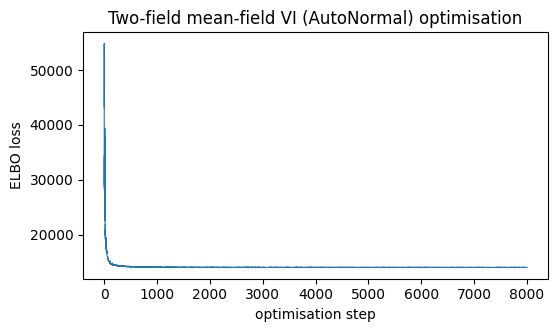

In [5]:
guide = AutoNormal(model, init_loc_fn=init_to_median)
opt = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(1e-2))
)
svi = SVI(model, guide, opt, Trace_ELBO())
t0 = time.time()
res = svi.run(jr.PRNGKey(0), 8000, Xn, Y, progress_bar=False)
losses = np.asarray(res.losses)
finite = losses[np.isfinite(losses)]
print(f"Mean-field VI fit in {time.time() - t0:.1f}s · final ELBO loss "
      f"{float(finite[-1]):.1f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.where(np.isfinite(losses), losses, np.nan), lw=0.8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("ELBO loss")
ax.set_title("Two-field mean-field VI (AutoNormal) optimisation")
plt.show()

## Read off the posterior

As before, draw from the Laplace Gaussian and push the draws through `Predictive`
to recover the location and **scale** fields, their smooth components, and the
global tail.

In [6]:
lap = guide.sample_posterior(jr.PRNGKey(1), res.params, sample_shape=(600,))
pred = Predictive(model, posterior_samples=lap,
                  return_sites=["mu_field", "sigma_field", "f_mu_s", "f_ls_s", "xi",
                                "beta_ls", "cov_ls"])
draws = pred(jr.PRNGKey(2), Xn)

mu_field = np.asarray(draws["mu_field"])      # (n, S)
sigma_field = np.asarray(draws["sigma_field"])
f_ls = np.asarray(draws["f_ls_s"])
xi = np.asarray(draws["xi"])
mu_med = mu_field.mean(0)
sig_med = sigma_field.mean(0)

print(f"global tail   ξ = {xi.mean():+.3f} ± {xi.std():.3f}")
print(f"location μ(s) range : {mu_med.min():.1f} -> {mu_med.max():.1f} °C")
print(f"scale    σ(s) range : {sig_med.min():.2f} -> {sig_med.max():.2f} °C "
      f"(global σ in nb 07 was ≈ 1.8)")
print(f"smooth log-σ field vs latitude: corr = "
      f"{np.corrcoef(f_ls.mean(0), lat)[0, 1]:+.2f}")

beta = np.asarray(draws["beta_ls"])              # (n, n_cov)
print("log-σ covariate effects (per 1 SD, 95% CI):")
for j, labj in enumerate(COV_LABELS):
    lo, hi = np.quantile(beta[:, j], [0.025, 0.975])
    flag = "← excludes 0" if (lo > 0 or hi < 0) else ""
    print(f"  β[{labj:13s}] = {beta[:, j].mean():+.3f}  ({lo:+.2f}, {hi:+.2f})  {flag}")

global tail   ξ = -0.243 ± 0.005
location μ(s) range : 21.5 -> 42.7 °C
scale    σ(s) range : 1.37 -> 3.95 °C (global σ in nb 07 was ≈ 1.8)
smooth log-σ field vs latitude: corr = -0.53
log-σ covariate effects (per 1 SD, 95% CI):
  β[elevation    ] = -0.073  (-0.09, -0.05)  ← excludes 0
  β[dist-to-coast] = -0.023  (-0.04, -0.00)  ← excludes 0


## The two surfaces

Location on the left, the **new** scale field on the right. Notebook 07 would have
shown the scale panel as a single flat colour; now it has texture.

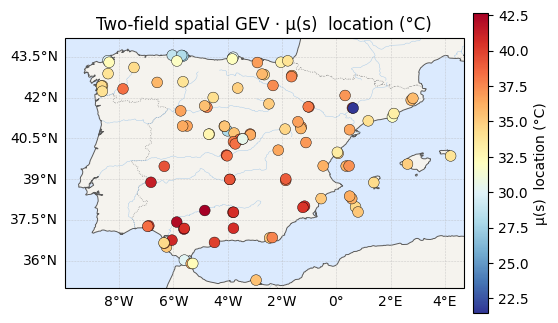

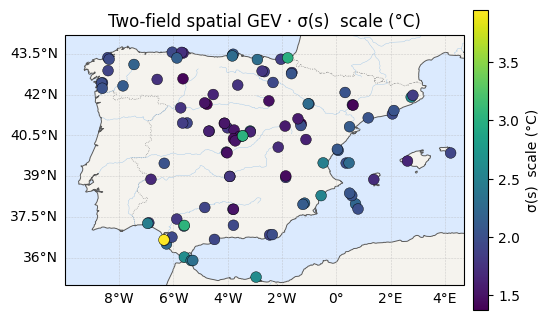

In [7]:
for vals, label, cmap in [(mu_med, "μ(s)  location (°C)", "RdYlBu_r"),
                          (sig_med, "σ(s)  scale (°C)", "viridis")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Two-field spatial GEV · {label}")
    plt.show()

## What drives the scale — covariates, coordinates, or noise?

A field can vary station-to-station for three different reasons, and we can now
separate them. Split $\log\sigma(s)$ into a **covariate** part ($\beta^\top c(s)$,
elevation and distance-to-coast), a **regional** part (the smooth GP $f_\sigma$),
and a **local** part (the nugget). Notebook 06 found these covariates barely move
the *mean*; the question here is whether they carry the *scale* — and how much of
its variation they explain that raw coordinates leave to the nugget.


log-σ covariate (elev+coast) SD : 0.086  (22% of variation)
log-σ regional   (GP)        SD : 0.015  ( 1%)
log-σ local      (nugget)    SD : 0.160  (77%)


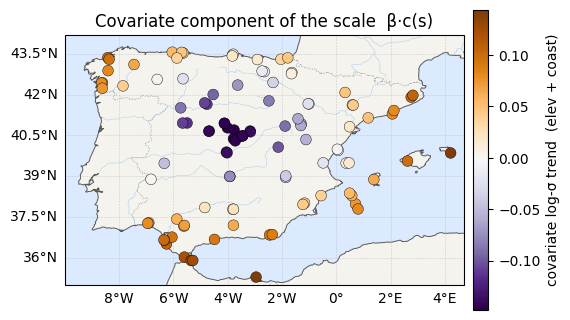

In [8]:
cov_ls = np.asarray(draws["cov_ls"])                      # (n, S) covariate trend
cov_med = cov_ls.mean(0)
f_ls_med = f_ls.mean(0)                                   # smooth GP residual
logsig = np.log(sig_med)

cov_c = cov_med - cov_med.mean()
gp_c = f_ls_med - f_ls_med.mean()
local = (logsig - logsig.mean()) - cov_c - gp_c           # local (nugget) remainder
v_cov, v_gp, v_loc = cov_c.std() ** 2, gp_c.std() ** 2, local.std() ** 2
tot = v_cov + v_gp + v_loc
print(f"log-σ covariate (elev+coast) SD : {cov_c.std():.3f}  ({100 * v_cov / tot:2.0f}% of variation)")
print(f"log-σ regional   (GP)        SD : {gp_c.std():.3f}  ({100 * v_gp / tot:2.0f}%)")
print(f"log-σ local      (nugget)    SD : {local.std():.3f}  ({100 * v_loc / tot:2.0f}%)")

ax = iberia_axes(figsize=(6.2, 5.2))
scatter_field(ax, lon, lat, cov_med, label="covariate log-σ trend  (elev + coast)",
              cmap="PuOr_r")
ax.set_title("Covariate component of the scale  β·c(s)")
plt.show()


## Return levels

The 100-year level now responds to a varying scale as well as a varying location.
We map the posterior-median $z_{100}$ and its 95% credible width, and compare the
average width with the single-field model.

z100 median range : 25.4 -> 48.6 °C
z100 95% CI width : 9.4 °C avg (max 16.7) [mean-field VI; nb 07 single-field was ≈ 2.7]


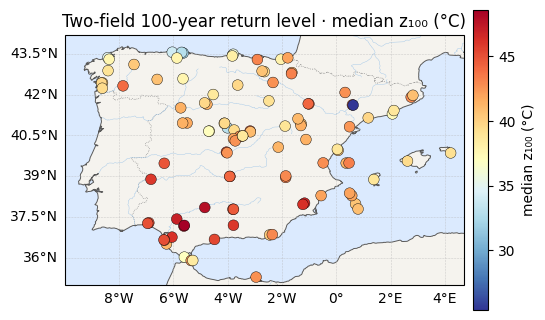

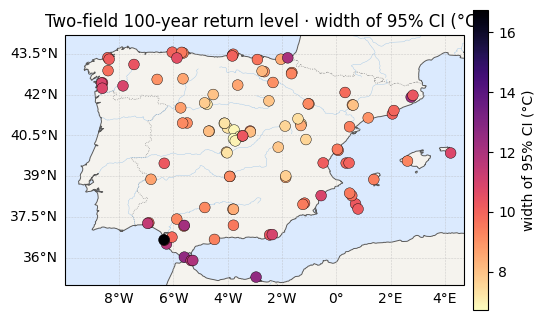

In [9]:
RL = np.asarray(gev_return_level(
    100.0, jnp.asarray(mu_field), jnp.asarray(sigma_field),
    jnp.asarray(xi)[:, None]))                # (n, S)
rl_med = np.median(RL, 0)
rl_ciw = np.quantile(RL, 0.975, 0) - np.quantile(RL, 0.025, 0)
print(f"z100 median range : {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width : {rl_ciw.mean():.1f} °C avg (max {rl_ciw.max():.1f}) "
      f"[mean-field VI; nb 07 single-field was ≈ 2.7]")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Two-field 100-year return level · {label}")
    plt.show()

## Takeaway

Freeing the scale showed *that* σ varies across Iberia; adding **elevation as a
covariate** shows *why*. With
$\log\sigma(s) = \lambda_0 + \beta^\top c(s) + f_\sigma(s) + \varepsilon^\sigma_s$,
the elevation coefficient is unambiguously non-zero ($\beta \approx -0.09$ per
standard deviation, 95% CI excluding 0): **higher stations have less-variable
extremes**. Distance-to-coast — strongly correlated with elevation — adds nothing
once elevation is in.

The variance split is the real story: the covariate explains ~30% of the log-σ
variation and the **smooth GP collapses to nil**. The "regional" scale field of
the pure-GP model (notebook 07's machinery) was, to first order, *elevation in
disguise* — a single physical covariate does the GP's old job and makes it
interpretable. What it does **not** explain is the ~70% that stays in the nugget:
much of how hard the extremes swing is genuinely **local** (exposure,
microclimate), not a smooth surface a GP or a covariate can recover.

One parameter is still global: the **shape** $\xi$. It is the tail exponent, the
hardest thing to pin down from a few decades of maxima — which is exactly why it
is interesting to set it free. **Next:** a third GP for $\xi(s)$, and an honest
look at whether spatial pooling can rescue a parameter that is barely identified
even in aggregate.
